# Monday, April 27th, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Conway's Game of Life

Conway's [Game of Life](https://conwaylife.com/wiki/Conway%27s_Game_of_Life) is a cellular automaton created by John Conway in 1970. It is a deterministic process where the next state of a population of cells depends only on the current state. We will use 2D NumPy arrays to represent the population of cells aranged in an $n \times n$ grid.
A value of `1` will signify that a cell is alive while a value of `0` will signify that a cell is dead.

### Starting configuration

Lets begin with an $ n\times n $ array of all 0s with a small three-block column (3$\times$1) of 1s in the middle. Use an integer datatype (`dtype=int`) when defining your array.

**Exercise:**  Write a function `starting_state(n)` that returns the array described above.

In [2]:
def starting_state(n):
    cells = np.zeros((n,n),dtype=int)
    mid = n//2
    cells[mid-1:mid+2, mid] = 1
    return cells

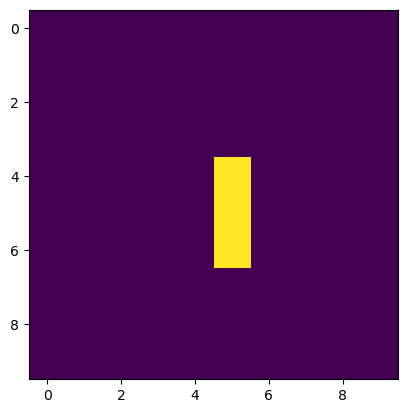

In [3]:
cells = starting_state(10)
plt.imshow(cells)

### Rules of Life

We will use the current state of the population to determine the next state.
In the Game of Life, each cell interacts with its eight neighbors (i.e. the horizontally, vertically, or diagonally adjacent cells).

![neighbors](https://jllottes.github.io/_images/epidemic-2.svg)

The rules of the Game of Life can be summarized as follows:

 1. Any live cell with two or three live neighbors survives.
 2. Any dead cell with with three live neighbors becomes a live cell.
 3. All other live cells die in the next generation, and all other dead cells stay dead.

### Counting the number of live neighbors

In order to update our array from one state to the next, we need to be able to count the number of live neighbors of the $(i,j)$th cell for any choice of $i,j$.

**Exercise:** Write a function `get_live_neighbors_count(cells,i,j)` that counts the number of living neighbors of the $(i,j)$th cell.

 - We handled a similar problem with the [Image Denoising](https://jllottes.github.io/Projects/image_denoising/image_denoising) project.
 - How can we handle cells on the edge of the grid?
 - The `np.sum` function will add all values in an array.
 - We want to exclude (or remove from the sum) the $(i,j)$th cell when counting the number of living neighbors.



In [4]:
def get_padded_cells(cells):
    nrows, ncols = cells.shape
    padded_cells = np.zeros((nrows+2, ncols+2), dtype=int)
    padded_cells[1:-1, 1:-1] = cells
    return padded_cells

In [5]:
def get_live_neighbors_count(cells, i, j):
    padded_cells = get_padded_cells(cells)
    grid = padded_cells[i:i+3, j:j+3]      # The 3x3 grid centered on
                                           # cells [i,j] of the cells array
    live_neighbors_count = np.sum(grid) - cells[i,j]
    return live_neighbors_count

Let's test this on our configuration of a `3` by `1` column of live cells:

Cell [4, 5] has 1 live neighbors
Cell [5, 5] has 2 live neighbors
Cell [6, 5] has 1 live neighbors
Cell [4, 6] has 2 live neighbors
Cell [5, 6] has 3 live neighbors
Cell [6, 6] has 2 live neighbors


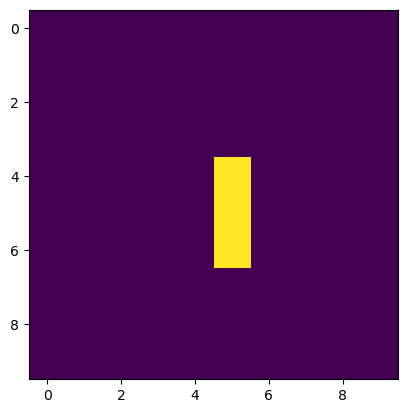

In [8]:
for i,j in [(4,5), (5,5), (6,5), (4,6), (5,6), (6,6)]:
    print('Cell [{}, {}] has {} live neighbors'.format(i,j,get_live_neighbors_count(cells, i, j)))
plt.imshow(cells)

### Updating the `cells` population

We can now update the `cells` array according to the rules.  We have to update every entry of the array, so we will need to loop through all the entries.

**Exercise:** Write a function `update_cells(cells)` that takes in a population array `cells`, applies the Rules of Life to update the population, and returns the updated population.

In [9]:
def update_cells(cells):
    nrows, ncols = cells.shape

    updated_cells = cells.copy()
    for i in range(nrows):
        for j in range(ncols):
            live_neighbors_count = get_live_neighbors_count(cells, i, j)
            if cells[i,j] == 1:     # If the cell is alive
                if live_neighbors_count in [2,3]: # And if it has two or three live neighbors
                    updated_cells[i,j] = 1       # then it stays alive
                else:                            # Otherwise,
                    updated_cells[i,j] = 0       # it dies
            elif cells[i,j] == 0:   # If the cell is dead
                if live_neighbors_count == 3:     # And if it has exactly three live neighbors
                    updated_cells[i,j] = 1       # then it becomes alive
                else:
                    updated_cells[i,j] = 0
    return updated_cells

In [10]:
cells = starting_state(10)
updated_cells = update_cells(cells)

(np.float64(-0.5), np.float64(9.5), np.float64(9.5), np.float64(-0.5))

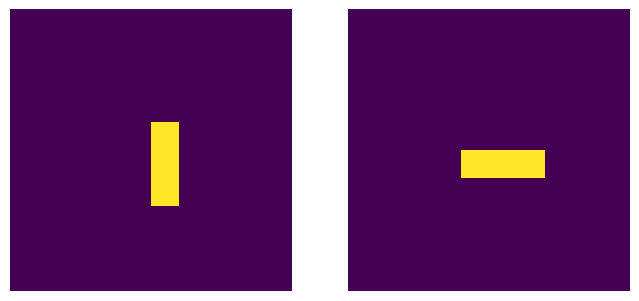

In [11]:
fig = plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cells)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(updated_cells)
plt.axis('off')

### Animating the dynamics

All of the figures that we've generated so far have been static, i.e. they do not change. Python also allows us to create interactive figures that can change over time. 

An easy way to activate this mode is to use the "magic", `%matplotlib qt`. Magics like this are not actual Python code, but instead are signals to Jupyter notebook that can be used to change various configuration options. This particular magic will enable interactive plotting and switch to using external plotting windows, instead of the inline plotting (i.e. appearing within the notebook) that we've been using.

*Note: Once we are finished with any interactive plotting, we can return to inline plotting using the magic `%matplotlib inline`.*

In [12]:
%matplotlib qt

Once we are in interactive mode, the `FuncAnimation` function from `matplotlib.animation` can be used to create animations.
It takes in a figure `fig` and function `animate`. The `animate` function should take in a frame index `i` and perform any desired updates to the figure.

For example, if we've stored the output of `plt.imshow` as `im`, we can update the displayed array using the `.set_data` method. That is, `im.set_data(new_array)` will change the figure to display the colorized data from `new_array`.

In [13]:
from matplotlib.animation import FuncAnimation

**Exercise:** Modify the code below to animate the Game of Life.

In [14]:
cells = starting_state(10)

fig = plt.figure()
im = plt.imshow(cells,vmin=0,vmax=1)

def animate(i):
    cells[:,:] = update_cells(cells)
    im.set_data(cells)
    return im

anim = FuncAnimation(fig,animate,save_count=100)
plt.show()

**Exercise:** Use `np.random.random` to randomly select an initial `cells` array of `0`s and `1`s.

In [15]:
def random_starting_state(n, percent_live_cells):
    cells = np.zeros((n,n), dtype=int)
    random_array = np.random.random((n,n))
    live_mask = random_array < percent_live_cells
    cells[live_mask] = 1
    return cells

In [16]:
cells = random_starting_state(200, .1)

fig = plt.figure()
im = plt.imshow(cells,vmin=0,vmax=1)

def animate(i):
    cells[:,:] = update_cells(cells)
    im.set_data(cells)
    return im

anim = FuncAnimation(fig,animate,save_count=100)
plt.show()

Let's create a function `animate_game_of_life` that takes in an array `cells` specifying the initial configuration and animates the Game of Life.

*Note: You may need this function to return the animation object returned by `FuncAnimation` (and then store the returned animation object when calling the function) in order for the animation to run properly.*

In [17]:
def animate_game_of_life(cells):
    fig = plt.figure()
    im = plt.imshow(cells,vmin=0,vmax=1)
    
    def animate(i):
        cells[:,:] = update_cells(cells)
        im.set_data(cells)
        return im
    
    anim = FuncAnimation(fig,animate,save_count=100)
    plt.show()
    return anim

What can we do to make our code run more efficiently? At a `200` by `200` grid, it is very slow to update. Let's look at the `get_live_neighbors_count` function, which will run $n^2$ times for an $n$ by $n$ grid. Any improvements we can make here will give big improvements to our code.

For example, our current `get_live_neighbors_count` function creates a padded version of the array before finding the neighbors. On the other hand, the padded version of the array is the same for every single cell. It would be better if we moved this operation outside of the `get_live_neighbors_count` function so that we only have to perform it once, then passed in the `padded_cells` array as the new input for `get_live_neighbors_count`.

**Exercise** Rewrite the `get_live_neighbors_count` to take `padded_cells` in as an input.

In [18]:
def get_live_neighbors_count(padded_cells, i, j):
    grid = padded_cells[i:i+3, j:j+3]      # The 3x3 grid centered on
                                           # cells [i,j] of the cells array
    live_neighbors_count = np.sum(grid) - grid[1,1]
    return live_neighbors_count

**Exercise**: Rewrite the `update_cells` function to generate the `padded_cells` array and pass it into the  `get_live_neighbors_count` function.

In [21]:
def update_cells(cells):
    nrows, ncols = cells.shape
    padded_cells = get_padded_cells(cells)

    updated_cells = cells.copy()
    for i in range(nrows):
        for j in range(ncols):
            live_neighbors_count = get_live_neighbors_count(padded_cells, i, j)
            if cells[i,j] == 1:     # If the cell is alive
                if live_neighbors_count in [2,3]: # And if it has two or three live neighbors
                    updated_cells[i,j] = 1       # then it stays alive
                else:                            # Otherwise,
                    updated_cells[i,j] = 0       # it dies
            elif cells[i,j] == 0:   # If the cell is dead
                if live_neighbors_count == 3:     # And if it has exactly three live neighbors
                    updated_cells[i,j] = 1       # then it becomes alive
                else:
                    updated_cells[i,j] = 0
    return updated_cells

Let's see how this helps the speed of our animation.

In [22]:
cells = random_starting_state(200, .1)

anim = animate_game_of_life(cells)

## Analyzing the dynamics of the Game of Life

Letting the Game of Life play out and observing the animation helps give us a sense of the resulting dynamics, but it is difficult to make meaningful quantitative statements about what is happening. We would like be able to distill this animation into some data that we can more easily describe.

With our current code, we're constantly overwriting the `cells` array to store the current state only. It would be useful to maintain a history of all states of `cells`. Let's create a new variable, `cells_history` that will contain each iteration of `cells`. Let's also set a specific number of time steps that we will carry out.

Now, we want to iterate through the time steps and update our `cells` array and place its updated contents into the appropriate slice of `cells_history`.

In [23]:
T = 100 # Number of steps to simulate
n = 200  # Grid
percent_live_cells = .1

cells = random_starting_state(n, percent_live_cells)  # Initial configuration
cells_history = np.zeros((n,n,T), dtype=int)        # 3D array to store all configurations of cells

cells_history[:,:,0] = cells     # Store the initial configuration

for t in range(1,T):
    cells = update_cells(cells)
    cells_history[:,:,t] = cells

In [24]:
plt.imshow(cells_history[:,:,-1], vmin=0, vmax=1)

Let's use the code above to create a function that simulates the Game of Life with a given initial configuration for a given number of time steps and returns an array containing the entire history of configurations.

In [25]:
def simulate_game_of_life(cells, T):
    cells_history = np.zeros((n,n,T), dtype=int)        # 3D array to store all configurations of cells
    cells_history[:,:,0] = cells     # Store the initial configuration
    
    for t in range(1,T):
        cells = update_cells(cells)
        cells_history[:,:,t] = cells
    return cells_history

In [26]:
T = 100 # Number of steps to simulate
n = 200  # Grid
percent_live_cells = .1

cells = random_starting_state(n, percent_live_cells)  # Initial configuration
cells_history = simulate_game_of_life(cells, T)

We have all of this data, and now we want to visualize it. First, let's switch back to inline plotting using the magic, `%matplotlib inline`.

In [27]:
%matplotlib inline

One challenge we have is with the dimensionality of our data. Each data point corresponds to a row position, a column position, and a time position.


One way to reduce the dimensionality is to look at particular time indices. For example, we could create a 2x2 grid of subplots that show different time indices.

*Note: the `enumerate` function will zip together a list of indices (starting at `0`) with a supplied iterable (e.g. list). This is useful whenever we want to iterate through a list while also having access to each element's corresponding index. In this case, we can use the index to select a subplot.*

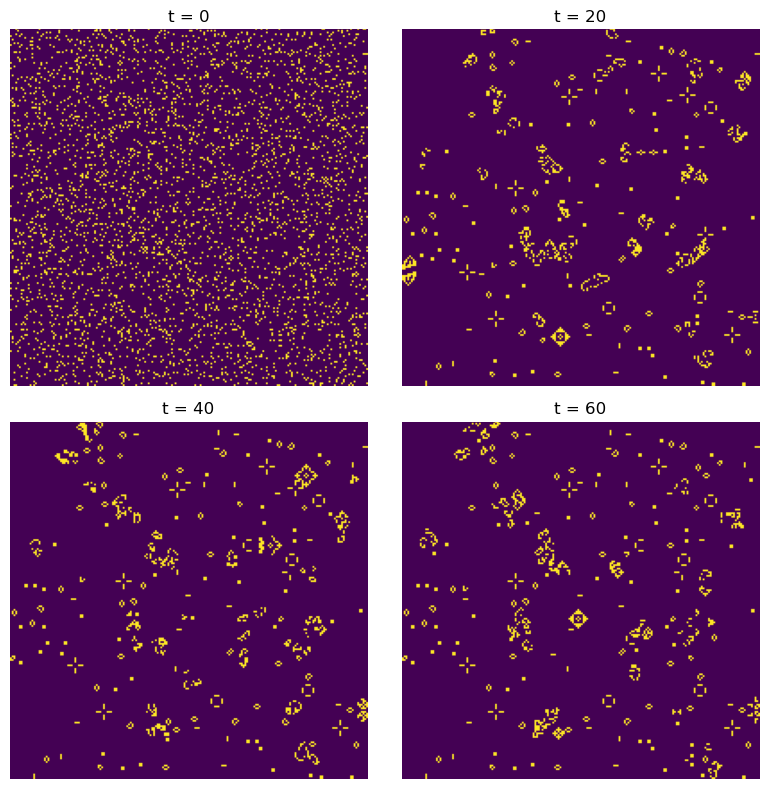

In [28]:
time_slices = [0, 20, 40, 60]

plt.figure(figsize=(8,8))

for i, t in enumerate(time_slices):
    plt.subplot(2,2,i+1)
    plt.imshow(cells_history[:,:,t])
    plt.title('t = {}'.format(t))
    plt.axis('off')

plt.tight_layout()
plt.show()

Another strategy to reduce the dimesionality is to condense the geometric information (i.e. the information in the first two dimensions of `cells_history`) into a single number per time step so that we could plot this quantity against time (i.e. against the third dimension).

For example, we could count the number of live cells during each time step and plot this against time.

*Recall: We can use `np.sum` together with the `axis` keyword argument to compute sums through a particular dimension (or dimensions). In this case, we would want to take the sum through the row and column dimensions (but not the time dimension) to count up the total number of live cells at each time step.*

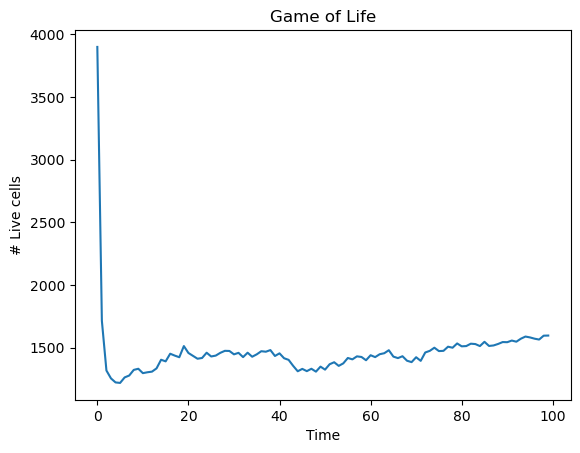

In [29]:
num_live_cells = cells_history.sum(axis=(0,1))

t = np.arange(T)
plt.plot(t, num_live_cells)

plt.xlabel('Time')
plt.ylabel('# Live cells')
plt.title('Game of Life')

plt.show()

*Another idea:* Let's generate a heatmap that indicates how often each cell was alive.

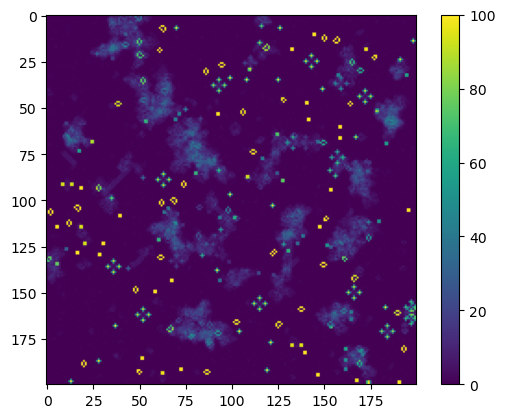

In [30]:
num_time_steps_alive = cells_history.sum(axis=2)

plt.imshow(num_time_steps_alive)
plt.colorbar()
plt.show()